In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from  ipywidgets import interact,widgets

In [89]:
df=pd.read_csv("../Datasets/FRED-NROUST.csv")

In [90]:
Y_train=df["Value"].iloc[:-8]
Y_test=df["Value"].iloc[-8:]

In [91]:
Y_train.shape,Y_test.shape

((288,), (8,))

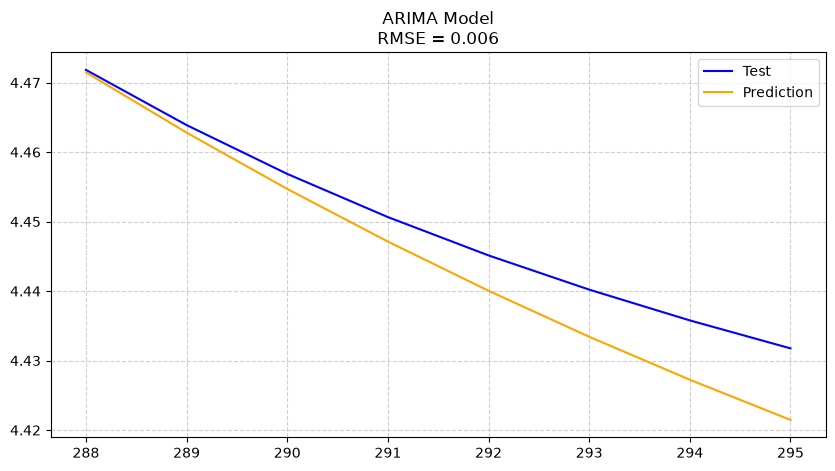

In [92]:
arima = ARIMA(Y_train, order=(1, 1, 1))
model_fit = arima.fit()

# Forecast strictly for the duration of the test set
prediction = model_fit.forecast(steps=len(Y_test))

# Plot results
plt.figure(figsize=(10, 5))
Y_test.plot(color="blue", label="Test")
prediction.plot(color="orange", label="Prediction")

# Calculate RMSE
rmse = root_mean_squared_error(Y_test, prediction)
plt.title(f"ARIMA Model\nRMSE = {rmse:.3f}")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [93]:
import matplotlib.pyplot as plt
from ipywidgets import interact
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA


# Rename function and inner variable to avoid variable shadowing
def run_arima(p, d, q):
    # Fit ARIMA model
    model = ARIMA(Y_train, order=(p, d, q))
    model_fit = model.fit()

    # Forecast strictly for the duration of the test set
    prediction = model_fit.forecast(start=len(Y_train),end=len(Y_test)+len(Y_train)-1)

    # Calculate RMSE
    rmse = root_mean_squared_error(Y_test, prediction)

    # Plot results
    plt.figure(figsize=(10, 5))
    Y_test.plot(color="blue", label="Test Set", linewidth=1.5)
    prediction.plot(
        color="orange",
        label=f"ARIMA({p},{d},{q}) Forecast",
        linestyle="--",
        linewidth=2,
    )

    plt.title(f"ARIMA({p},{d},{q}) Model\nRMSE = {rmse:.3f}")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


# Interactive sliders
interact(run_arima, p=(0, 5, 1), d=(0, 5, 1), q=(0, 5, 1))

interactive(children=(IntSlider(value=2, description='p', max=5), IntSlider(value=2, description='d', max=5), …

<function __main__.run_arima(p, d, q)>

In [94]:
from pmdarima import auto_arima

In [95]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [96]:
model=auto_arima(Y_train,trace=True,error_action='ignore',suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-1723.154, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=-1732.540, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=-1730.411, Time=0.06 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=-1732.234, Time=0.05 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=-1731.316, Time=0.02 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=-1735.903, Time=0.16 sec
 ARIMA(3,2,1)(0,0,0)[0]             : AIC=-1733.196, Time=0.03 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=-1731.076, Time=0.06 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=-1734.135, Time=0.04 sec
 ARIMA(3,2,2)(0,0,0)[0]             : AIC=-1734.099, Time=0.21 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=-1728.821, Time=0.17 sec

Best model:  ARIMA(2,2,1)(0,0,0)[0]          
Total fit time: 1.066 seconds


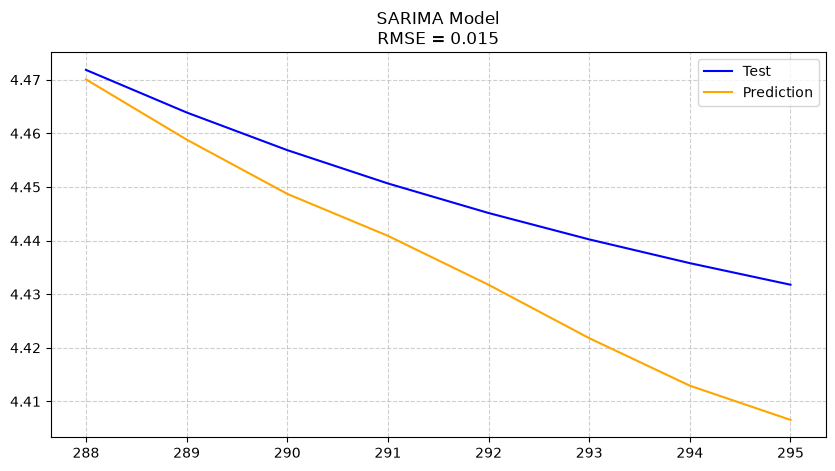

In [97]:
# Seasonal SARIMA

model=ARIMA(Y_train,order=(1,1,1),seasonal_order=(1,1,1,4))
fit=model.fit()
predict=fit.forecast(steps=len(Y_test))
# Plot results
plt.figure(figsize=(10, 5))
Y_test.plot(color="blue", label="Test")
predict.plot(color="orange", label="Prediction")

# Calculate RMSE
rmse = root_mean_squared_error(Y_test, predict)
plt.title(f"SARIMA Model\nRMSE = {rmse:.3f}")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [100]:
import matplotlib.pyplot as plt
from ipywidgets import interact
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA


def run_sarima(p, d, q, P, D, Q):
    # Fit SARIMA model
    model = ARIMA(Y_train, order=(p, d, q), seasonal_order=(P, D, Q, 4))
    model_fit = model.fit()

    # Forecast strictly for the duration of the test set
    prediction = model_fit.forecast(start=len(Y_train),end=len(Y_train)+len(Y_test)-1)

    # Calculate RMSE
    rmse = root_mean_squared_error(Y_test, prediction)

    # Plot results
    plt.figure(figsize=(10, 5))
    Y_test.plot(color="blue", label="Test Set", linewidth=1.5)
    prediction.plot(
        color="orange",
        label=f"SARIMA({p},{d},{q})({P},{D},{Q})₄",
        linestyle="--",
        linewidth=2,
    )

    plt.title(f"SARIMA({p},{d},{q})({P},{D},{Q})₄ Model\nRMSE = {rmse:.3f}")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend(loc="best")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


# Interactive Sliders
interact(
    run_sarima,
    p=(0, 3, 1),
    d=(0, 2, 1),
    q=(0, 3, 1),
    P=(0, 2, 1),
    D=(0, 1, 1),
    Q=(0, 2, 1),
)

interactive(children=(IntSlider(value=1, description='p', max=3), IntSlider(value=1, description='d', max=2), …

<function __main__.run_sarima(p, d, q, P, D, Q)>

In [99]:
model = auto_arima(
    Y_train,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    seasonal=True,
    m=4
)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[4]             : AIC=-1729.585, Time=0.39 sec
 ARIMA(0,2,0)(0,0,0)[4]             : AIC=-1723.154, Time=0.02 sec
 ARIMA(1,2,0)(1,0,0)[4]             : AIC=-1741.408, Time=0.12 sec
 ARIMA(0,2,1)(0,0,1)[4]             : AIC=-1741.380, Time=0.17 sec
 ARIMA(1,2,0)(0,0,0)[4]             : AIC=-1732.540, Time=0.02 sec
 ARIMA(1,2,0)(2,0,0)[4]             : AIC=-1749.829, Time=0.14 sec
 ARIMA(1,2,0)(2,0,1)[4]             : AIC=-1747.915, Time=0.23 sec
 ARIMA(1,2,0)(1,0,1)[4]             : AIC=-1745.318, Time=0.19 sec
 ARIMA(0,2,0)(2,0,0)[4]             : AIC=-1735.133, Time=0.03 sec
 ARIMA(2,2,0)(2,0,0)[4]             : AIC=-1748.154, Time=0.32 sec
 ARIMA(1,2,1)(2,0,0)[4]             : AIC=-1747.825, Time=0.19 sec
 ARIMA(0,2,1)(2,0,0)[4]             : AIC=-1746.928, Time=0.18 sec
 ARIMA(2,2,1)(2,0,0)[4]             : AIC=-1746.902, Time=0.33 sec
 ARIMA(1,2,0)(2,0,0)[4] intercept   : AIC=-1747.839, Time=0.31 sec

Best model:  ARIMA